## Práctica #3
### Aplicación de algoritmo de clustering k-means para segmentar imagenes en regiones de color similares y analizar resultados al variar el número de clusters.


Se comienza el código haciendo imports de numpy, matplotlib, cv2, sklearn y funciones específicas.

In [19]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
from sklearn.cluster import KMeans
import matplotlib.patches as mpatches

Se realiza la carga de la imagen de ejemplo y se hace un resize para facilitar el tiempo de procesamiento. Se añade una visualización de la imagen base.

Text(0.5, 1.0, 'Imagen Original')

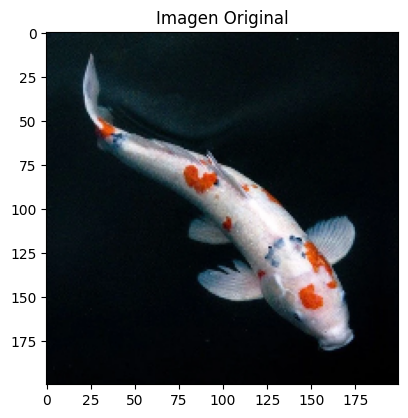

In [20]:
# Cargar la imagen a color
baseimg = cv2.imread(r"C:\Users\CALEM\Desktop\pez-koi.png")
baseimg = cv2.resize(baseimg, (200, 200))

# Visualizar la imagen original y extraer los valores RGB
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(baseimg, cv2.COLOR_BGR2RGB))
plt.title("Imagen Original")

Creación de una grafica 3D para observar la dispersión de pixeles en ejes RGB.

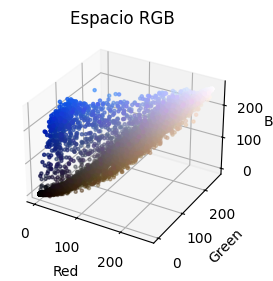

In [21]:
# Grafica 3D del espacio RGB via Matplotlib
ax = plt.subplot(1, 2, 2, projection='3d')
ax.scatter(baseimg[:, :, 0].flatten(), baseimg[:, :, 1].flatten(), baseimg[:, :, 2].flatten(), c=baseimg.reshape(-1, 3) / 255.0, marker='.')
ax.set_xlabel('Red')
ax.set_ylabel('Green')
ax.set_zlabel('Blue')
ax.set_title("Espacio RGB")
plt.show()

Se aplica K-means y grafica el resultado junto a los colores promedio. Se utilizan ciclos y arreglos para facilitar la visualización de resultados.

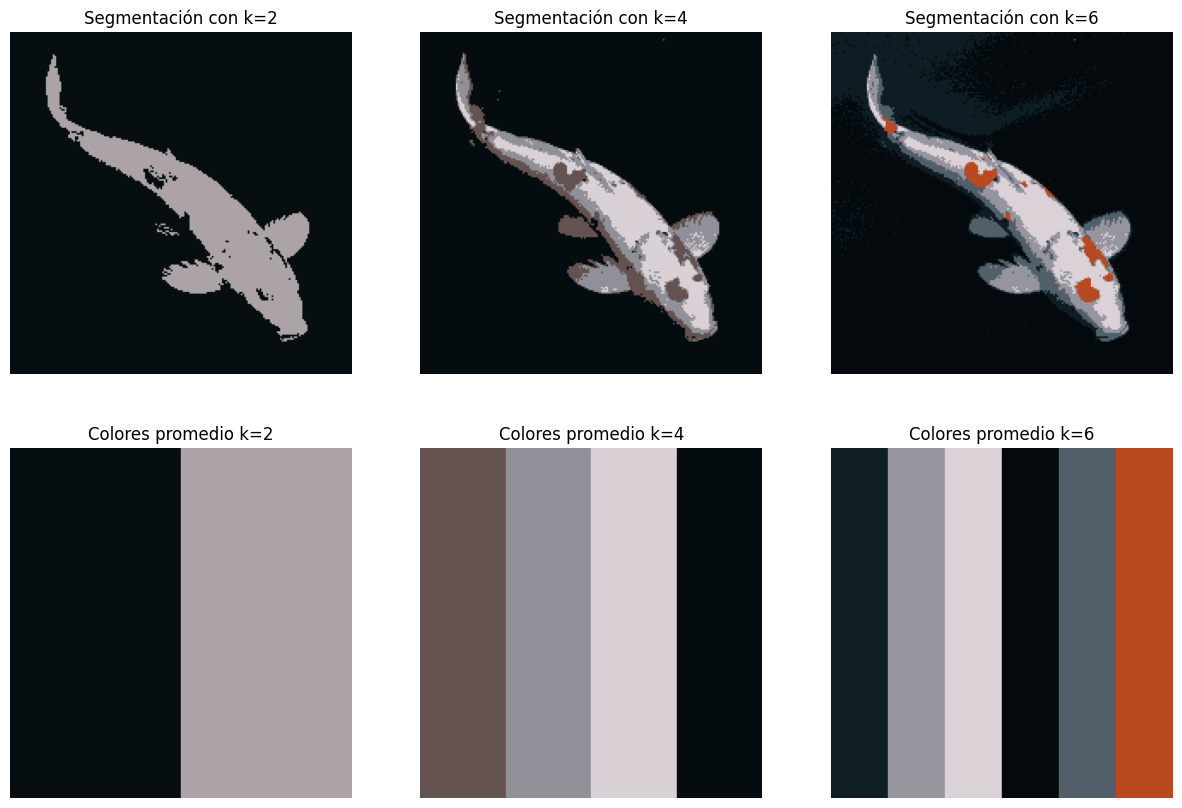

In [22]:
# Realizar K-means para diferentes valores de k
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
for i, k in enumerate([2, 4, 6]):
    kmeans = KMeans(n_clusters=k, random_state=0).fit(baseimg.reshape(-1, 3))
    labels = kmeans.labels_
    segmented_img = kmeans.cluster_centers_[labels].reshape(baseimg.shape).astype(np.uint8)
    axes[0, i].imshow(cv2.cvtColor(segmented_img, cv2.COLOR_BGR2RGB))
    axes[0, i].set_title(f"Segmentación con k={k}")
    axes[0, i].axis('off')
    
    # Mostrar colores promedio de cada cluster
    colors = kmeans.cluster_centers_ / 255.0
    colors_rgb = colors[:, [2, 1, 0]]
    for j in range(k):
        rect = mpatches.Rectangle((j / k, 0), 1/k, 1, color=colors_rgb[j])
        axes[1, i].add_patch(rect)
    axes[1, i].set_xlim(0, 1)
    axes[1, i].set_ylim(0, 1)
    axes[1, i].set_title(f"Colores promedio k={k}")
    axes[1, i].axis('off')
plt.show()

Se corre nuevamente el código con una imagen de ejemplo distinta.

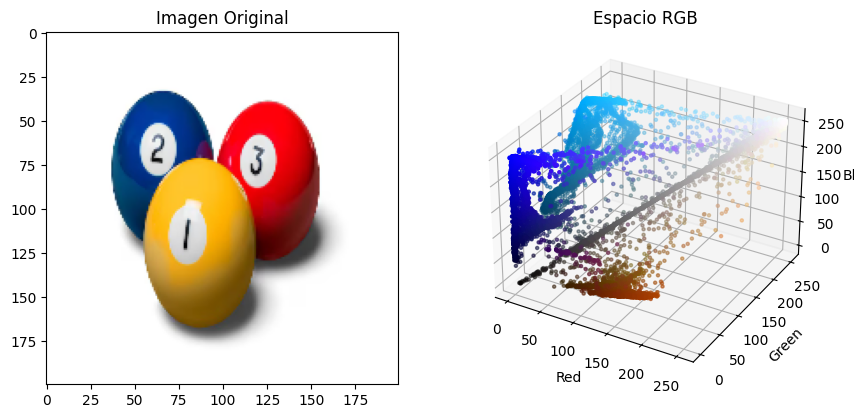

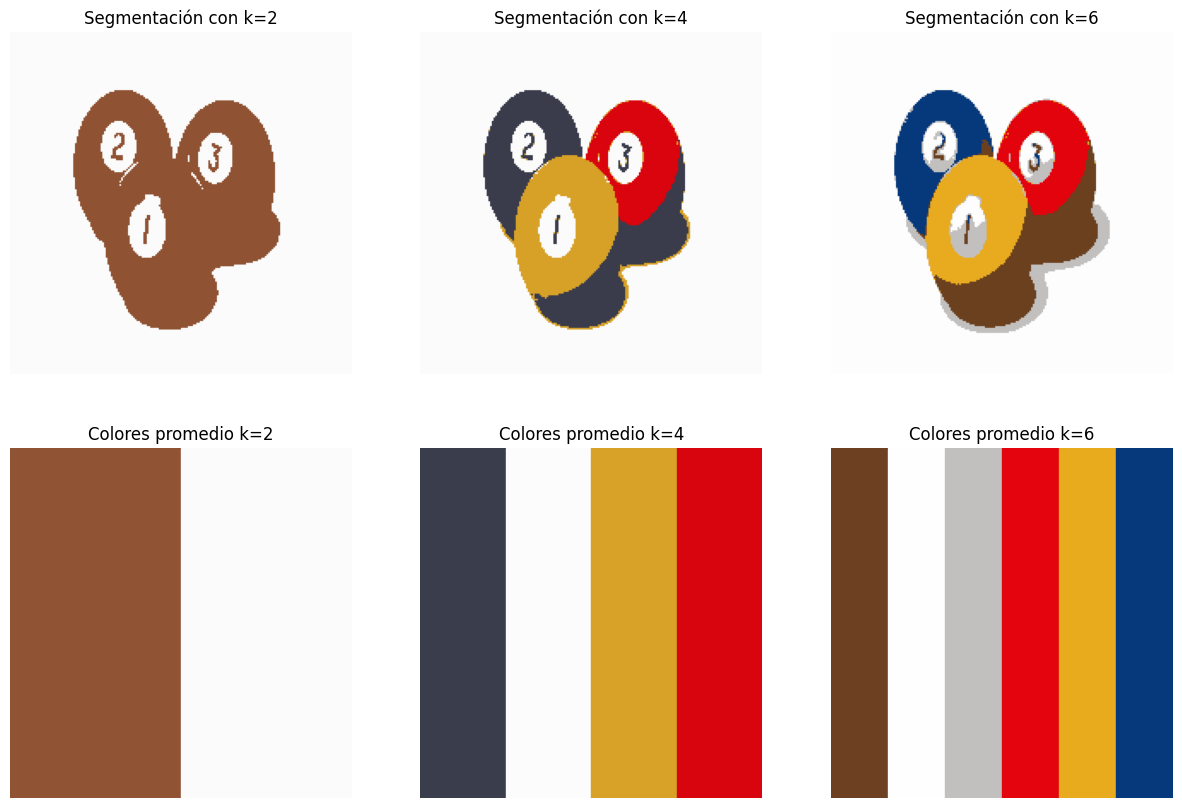

In [23]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
from sklearn.cluster import KMeans
import matplotlib.patches as mpatches
    
# Cargar la imagen a color
baseimg = cv2.imread(r"C:\Users\CALEM\Desktop\billardballs.png")

# Resize de la imagen para reducir el tiempo de procesamiento
baseimg = cv2.resize(baseimg, (200, 200))

# Visualizar la imagen original y extraer los valores RGB
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(baseimg, cv2.COLOR_BGR2RGB))
plt.title("Imagen Original")

# Grafico 3D del espacio RGB via Matplotlib
ax = plt.subplot(1, 2, 2, projection='3d')
ax.scatter(baseimg[:, :, 0].flatten(), baseimg[:, :, 1].flatten(), baseimg[:, :, 2].flatten(), c=baseimg.reshape(-1, 3) / 255.0, marker='.')
ax.set_xlabel('Red')
ax.set_ylabel('Green')
ax.set_zlabel('Blue')
ax.set_title("Espacio RGB")
plt.show()

# Realizar K-means para diferentes valores de k
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
for i, k in enumerate([2, 4, 6]):
    kmeans = KMeans(n_clusters=k, random_state=0).fit(baseimg.reshape(-1, 3))
    labels = kmeans.labels_
    segmented_img = kmeans.cluster_centers_[labels].reshape(baseimg.shape).astype(np.uint8)
    axes[0, i].imshow(cv2.cvtColor(segmented_img, cv2.COLOR_BGR2RGB))
    axes[0, i].set_title(f"Segmentación con k={k}")
    axes[0, i].axis('off')
    
    # Mostrar colores promedio de cada cluster
    colors = kmeans.cluster_centers_ / 255.0
    colors_rgb = colors[:, [2, 1, 0]]
    for j in range(k):
        rect = mpatches.Rectangle((j / k, 0), 1/k, 1, color=colors_rgb[j])
        axes[1, i].add_patch(rect)
    axes[1, i].set_xlim(0, 1)
    axes[1, i].set_ylim(0, 1)
    axes[1, i].set_title(f"Colores promedio k={k}")
    axes[1, i].axis('off')
plt.show()